# Methanol dehydrogenation model evaluation

This notebook evaluates machine learning models for:
1. Reaction rate prediction
2. Selectivity prediction
3. Multi-target prediction using target-wise wrappers
4. Native joint multi-output prediction


In [1]:
!pip install catboost xgboost tabpfn-client tabicl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.9/252.9 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.6/254.6 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.6 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
import os
import copy
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.base import clone
from sklearn.multioutput import MultiOutputRegressor

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from tabpfn_client import TabPFNRegressor, init
from tabicl import TabICLRegressor

from google.colab import drive, files
drive.mount("/content/drive")

init()

Mounted at /content/drive


########  ########   ###  #########  #########       ###         #####     ########  ########
     ###        ##   ###  ###   ###        ###       ###        ###  ###   ##   ###  ###     
########  #######    ###  ###   ###  #######         ###        ########   ######    ########
###       ###   ##   ###  ###   ###  ###   ###       ###        ###  ###   ##   ###       ###
###       ###   ##   ###  #########  ###   ###       ########   ###  ###   ########  ########                      

Thanks for being part of the journey

TabPFN is under active development, please help us improve and report any bugs/ideas you find.

Report issues: https://github.com/priorlabs/tabpfn-client/issues

...

Login

Email:

michel.youssef@epfl.ch
Password: ··········


Output()

Login successful!

In [3]:
RESULTS_DIR = "/content/drive/MyDrive/AIforchem_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Results will be saved in:", RESULTS_DIR)


def save_checkpoint(df, filename):
    if df is None or df.empty:
        print(f"Not saving {filename}: dataframe is empty.")
        return

    path = os.path.join(RESULTS_DIR, filename)
    df.to_csv(path, index=False)
    print(f"Saved: {path}")


def load_checkpoint(filename):
    path = os.path.join(RESULTS_DIR, filename)

    if not os.path.exists(path):
        print(f"No checkpoint found: {path}")
        return None

    if os.path.getsize(path) == 0:
        print(f"Checkpoint exists but is empty: {path}")
        return None

    try:
        df = pd.read_csv(path)
    except pd.errors.EmptyDataError:
        print(f"Checkpoint exists but has no readable data: {path}")
        return None

    print(f"Loaded: {path}")
    return df

Results will be saved in: /content/drive/MyDrive/AIforchem_results


In [4]:
def smape_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.abs(y_true) + np.abs(y_pred)

    smape_values = np.divide(
        2.0 * np.abs(y_pred - y_true),
        denominator,
        out=np.zeros_like(y_true, dtype=float),
        where=denominator != 0
    )

    return 100.0 * np.mean(smape_values)


def multioutput_smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)

    smape_per_target = []

    for j in range(y_true.shape[1]):
        smape_per_target.append(smape_score(y_true[:, j], y_pred[:, j]))

    return np.mean(smape_per_target)


def multioutput_nrmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)

    rmse_per_target = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
    range_per_target = np.max(y_true, axis=0) - np.min(y_true, axis=0)

    nrmse_per_target = np.divide(
        rmse_per_target,
        range_per_target,
        out=np.full_like(rmse_per_target, np.nan, dtype=float),
        where=range_per_target != 0
    )

    return np.nanmean(nrmse_per_target)


def smape_per_target(y_true, y_pred, target_cols):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)

    results = {}

    for j, target in enumerate(target_cols):
        results[target] = smape_score(y_true[:, j], y_pred[:, j])

    return results

In [5]:
uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No file was uploaded.")

file_path = list(uploaded.keys())[0]

print("Uploaded file:", file_path)

# Try common separators and keep the one giving the most columns
candidate_separators = [";", ",", "\t"]
best_df = None
best_sep = None
best_ncols = 0

for sep in candidate_separators:
    try:
        tmp_df = pd.read_csv(
            file_path,
            sep=sep,
            encoding="utf-8-sig"
        )

        ncols = tmp_df.shape[1]

        print(f"Separator {repr(sep)} gives {ncols} columns.")

        if ncols > best_ncols:
            best_df = tmp_df
            best_sep = sep
            best_ncols = ncols

    except Exception as e:
        print(f"Separator {repr(sep)} failed:", repr(e))

if best_df is None:
    raise ValueError("Could not read the uploaded file with common separators.")

cat_data = best_df.copy()

cat_data = cat_data.dropna(axis=1, how="all")
cat_data = cat_data.dropna(how="all")

print("Selected separator:", repr(best_sep))
print("Dataset shape after cleaning:", cat_data.shape)
print("Columns:")
print(cat_data.columns.tolist())

display(cat_data.head())

Saving CPEC Chemical Catalysis Database_CatTestHub_modified.csv to CPEC Chemical Catalysis Database_CatTestHub_modified.csv
Uploaded file: CPEC Chemical Catalysis Database_CatTestHub_modified.csv
Separator ';' gives 45 columns.
Separator ',' gives 6 columns.
Separator '\t' gives 1 columns.
Selected separator: ';'
Dataset shape after cleaning: (96, 34)
Columns:
['Unique Identifier', 'Metal', 'Support', 'Weight loading [%]', 'Molecular Weight of Active component [g mol-1]', 'Catalyst ID', 'Active Site Density [µmol gcat-1]', 'Dispersion [%]', 'Method of determining Active Site Density', 'Pellet Diameter [µm]', 'Weight Hourly Space Velocity [gCH3OH gcat-1 hr-1]', 'Temperature [K]', 'Total Pressure [kPa]', 'Inlet Inert Used', 'Inert, Inlet Mole fraction [%] ', 'CO, Inlet Mole fraction [%]', 'CH4, Inlet Mole Fraction [%]', 'Methanol, Inlet Mole fraction [%]', 'Inlet P,Methanol [kPa]', 'Inlet Inert Flow Rate [sccm]', 'Total Inlet Flow Rate [mol/hr]', 'Reactor Configuration', 'Reactor ID', 'R

,Unique Identifier,Metal,Support,Weight loading [%],Molecular Weight of Active component [g mol-1],Catalyst ID,Active Site Density [µmol gcat-1],Dispersion [%],Method of determining Active Site Density,Pellet Diameter [µm],...,Confidence Interval for Rate [μmol gcat-1 min-1],STY [mol product mol active site-1 hr-1 ],Selectivity CO [%],Selectivity CH4 [%],Selectivity CO2 [%],Conversion [%],Data Source,Data Submitted By,Funding Agency,Funding Identifier
0,MDH-0001,Platinum,Silica,1.0,195.08,Cat_M_000001,14.7,30.1,CO dynamic chemisorption,106 - 250,...,2.1,65.66,82.0,3.0,15.0,0.22,Abdelrahman Catalysis Research Laboratory,0009-0004-1407-1640,Department of Energy,DE-SC0023464
1,MDH-0002,Platinum,Silica,3.1,195.08,Cat_M_000002,14.0,8.5,CO static chemisorption,<1000,...,NaN,131.00,91.0,9.0,0.0,<5,10.1007/s11244-006-0001-1,0000-0002-9114-555X,National Science Foundation,CTS-0327959
2,MDH-0003,Platinum,Silica,3.1,195.08,Cat_M_000002,14.0,8.5,CO static chemisorption,<1000,...,NaN,8.30,87.0,13.0,0.0,<5,10.1007/s11244-006-0001-1,0000-0002-9114-555X,National Science Foundation,CTS-0327959
3,MDH-0004,Platinum,Silica,3.1,195.08,Cat_M_000002,14.0,8.5,CO static chemisorption,<1000,...,NaN,10.50,86.0,14.0,0.0,<5,10.1007/s11244-006-0001-1,0000-0002-9114-555X,National Science Foundation,CTS-0327959
4,MDH-0005,Platinum,Silica,3.1,195.08,Cat_M_000002,14.0,8.5,CO static chemisorption,<1000,...,NaN,33.20,91.0,9.0,0.0,<5,10.1007/s11244-006-0001-1,0000-0002-9114-555X,National Science Foundation,CTS-0327959


In [6]:
feature_cols = [
    "Metal",
    "Support",
    "Weight loading [%]",
    "Molecular Weight of Active component [g mol-1]",
    "Active Site Density [µmol gcat-1]",
    "Dispersion [%]",
    "Weight Hourly Space Velocity [gCH3OH gcat-1 hr-1]",
    "Temperature [K]",
    "Total Pressure [kPa]",
    "Inlet Inert Used",
    "Inert, Inlet Mole fraction [%] ",
    "CO, Inlet Mole fraction [%]",
    "CH4, Inlet Mole Fraction [%]",
    "Methanol, Inlet Mole fraction [%]",
    "Inlet P,Methanol [kPa]",
    "Inlet Inert Flow Rate [sccm]",
    "Total Inlet Flow Rate [mol/hr]"
]

rate_target = "Rate [μmol product gcat-1min-1]"

selectivity_targets = [
    "Selectivity CO [%]",
    "Selectivity CH4 [%]",
    "Selectivity CO2 [%]"
]

target_sets = {
    "Reaction rate": [rate_target],
    "CO selectivity": ["Selectivity CO [%]"],
    "All selectivities": [
        "Selectivity CO [%]",
        "Selectivity CH4 [%]",
        "Selectivity CO2 [%]"
    ],
    "Rate + CO selectivity": [
        rate_target,
        "Selectivity CO [%]"
    ],
    "Rate + all selectivities": [
        rate_target,
        "Selectivity CO [%]",
        "Selectivity CH4 [%]",
        "Selectivity CO2 [%]"
    ]
}

target_set_order = list(target_sets.keys())

split_list = [3, 5, 7, 9, 10, 12, 15, 20, 25]
random_seeds = [0, 1, 2, 3, 4]
fixed_k = 20

# IMPORTANT:
# This notebook expects a catalysis dataset with the same column names as the
# original methanol dehydrogenation dataset. If a different dataset is uploaded,
# update feature_cols, rate_target, selectivity_targets, and target_sets.

# -----------------------------
# Column validation
# -----------------------------

In [7]:
required_columns = feature_cols + [rate_target] + selectivity_targets

missing_columns = [
    col for col in required_columns
    if col not in cat_data.columns
]

if missing_columns:
    print("The dataset is missing the following required columns:")
    for col in missing_columns:
        print("-", col)

    raise ValueError(
        "Column mismatch detected. Update feature_cols, rate_target, "
        "selectivity_targets, and target_sets before running the experiments."
    )

print("Column validation passed. All required columns are present.")

Column validation passed. All required columns are present.


In [8]:
column_transformer = make_column_transformer(
    (
        OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        make_column_selector(dtype_include=["object", "category"])
    ),
    remainder="passthrough"
)

tabiclv2_model = make_pipeline(
    column_transformer,
    TabICLRegressor()
)

catboost_native_multi = make_pipeline(
    column_transformer,
    CatBoostRegressor(
        loss_function="MultiRMSE",
        random_state=42,
        verbose=0
    )
)

models = {
    "RandomForest": make_pipeline(
        column_transformer,
        RandomForestRegressor(
            n_estimators=200,
            random_state=42
        )
    ),
    "XGBoost": make_pipeline(
        column_transformer,
        XGBRegressor(
            n_estimators=200,
            random_state=42,
            objective="reg:squarederror"
        )
    ),
    "CatBoost": make_pipeline(
        column_transformer,
        CatBoostRegressor(
            random_state=42,
            verbose=0
        )
    ),
    "TabPFN": make_pipeline(
        column_transformer,
        TabPFNRegressor(random_state=42)
    ),
    "TabICLv2": tabiclv2_model
}

models_for_multitarget_wrapped = {
    "RandomForest": models["RandomForest"],
    "XGBoost": models["XGBoost"],
    "CatBoost": models["CatBoost"],
    "TabICLv2": tabiclv2_model
}

models_for_multitarget_native = {
    "RandomForest": models["RandomForest"],
    "XGBoost": models["XGBoost"],
    "CatBoost": catboost_native_multi
}

# ============================================================
# Generic checkpoint and completion utilities
# ============================================================

In [9]:
def ensure_results_table(filename, required_columns):
    """
    Load a checkpoint if it exists.
    If it does not exist, create an empty dataframe with required columns.
    If columns are missing, add them as NaN.
    """
    df = load_checkpoint(filename)

    if df is None:
        df = pd.DataFrame(columns=required_columns)
    else:
        for col in required_columns:
            if col not in df.columns:
                df[col] = np.nan

        df = df[required_columns].copy()

    # Coerce standard numeric columns when present
    numeric_cols = [
        "n_splits",
        "seed",
        "mean_rmse",
        "std_rmse",
        "mean_nrmse",
        "std_nrmse",
        "mean_smape",
        "std_smape"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def completed_result_exists(df, key_values, required_metric_columns):
    """
    Check whether a specific result row already exists and has all required metrics.
    key_values example:
        {
            "target": target_col,
            "model": model_name,
            "n_splits": n_splits,
            "seed": seed
        }
    """
    if df is None or df.empty:
        return False

    mask = np.ones(len(df), dtype=bool)

    for col, value in key_values.items():
        mask = mask & (df[col] == value)

    if not mask.any():
        return False

    row = df.loc[mask].iloc[-1]

    for col in required_metric_columns:
        if col not in row.index or pd.isna(row[col]):
            return False

    return True


def append_or_update_result(df, new_row, duplicate_subset):
    """
    Append one result row and remove duplicates, keeping the newest row.
    """
    df = pd.concat(
        [df, pd.DataFrame([new_row])],
        ignore_index=True
    )

    df = df.drop_duplicates(
        subset=duplicate_subset,
        keep="last"
    ).reset_index(drop=True)

    return df

# ============================================================
# Single-target evaluation
# Used for:
# - Reaction rate vs k-fold
# - Individual selectivity vs k-fold
# ============================================================

In [10]:
def prepare_single_target_data(target_col):
    X = cat_data[feature_cols].copy()
    y = pd.to_numeric(cat_data[target_col], errors="coerce")

    valid_rows = y.notna()
    X_target = X.loc[valid_rows].copy()
    y_target = y.loc[valid_rows].copy()

    return X_target, y_target


def evaluate_single_target_model(model, X, y, n_splits, seed):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    rmse_scores = []
    nrmse_scores = []
    smape_scores = []

    y_range_global = y.max() - y.min()

    for train_idx, test_idx in cv.split(X):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        fitted_model = clone(model)
        fitted_model.fit(X_train, y_train)

        y_pred = fitted_model.predict(X_test)
        y_pred = np.asarray(y_pred, dtype=float).reshape(-1)

        rmse = np.sqrt(np.mean((y_test.values - y_pred) ** 2))
        nrmse = rmse / y_range_global if y_range_global != 0 else np.nan
        smape = smape_score(y_test.values, y_pred)

        rmse_scores.append(rmse)
        nrmse_scores.append(nrmse)
        smape_scores.append(smape)

    rmse_scores = np.array(rmse_scores)
    nrmse_scores = np.array(nrmse_scores)
    smape_scores = np.array(smape_scores)

    return {
        "mean_rmse": rmse_scores.mean(),
        "std_rmse": rmse_scores.std(),
        "mean_nrmse": nrmse_scores.mean(),
        "std_nrmse": nrmse_scores.std(),
        "mean_smape": smape_scores.mean(),
        "std_smape": smape_scores.std()
    }


def run_single_target_experiment(results_file, target_cols, models_dict, split_list, random_seeds):
    required_columns = [
        "target",
        "model",
        "n_splits",
        "seed",
        "mean_rmse",
        "std_rmse",
        "mean_nrmse",
        "std_nrmse",
        "mean_smape",
        "std_smape"
    ]

    results_df = ensure_results_table(results_file, required_columns)

    required_metric_columns = [
        "mean_rmse",
        "std_rmse",
        "mean_nrmse",
        "std_nrmse",
        "mean_smape",
        "std_smape"
    ]

    for target_col in target_cols:
        print("\n==============================")
        print("Single-target experiment:", target_col)
        print("==============================")

        X_target, y_target = prepare_single_target_data(target_col)

        print("Samples:", len(X_target))

        if max(split_list) > len(X_target):
            raise ValueError(
                f"max(split_list)={max(split_list)} is larger than the number "
                f"of valid samples for {target_col}: {len(X_target)}"
            )

        for model_name, model in models_dict.items():
            print("\nModel:", model_name)

            for n_splits in split_list:
                print("  n_splits:", n_splits)

                for seed in random_seeds:
                    key_values = {
                        "target": target_col,
                        "model": model_name,
                        "n_splits": n_splits,
                        "seed": seed
                    }

                    if completed_result_exists(
                        results_df,
                        key_values,
                        required_metric_columns
                    ):
                        print(f"    Skipping existing: {target_col} | {model_name} | k={n_splits} | seed={seed}")
                        continue

                    print(f"    Running: {target_col} | {model_name} | k={n_splits} | seed={seed}")

                    try:
                        eval_result = evaluate_single_target_model(
                            model,
                            X_target,
                            y_target,
                            n_splits,
                            seed
                        )

                        new_row = {
                            "target": target_col,
                            "model": model_name,
                            "n_splits": n_splits,
                            "seed": seed,
                            "mean_rmse": eval_result["mean_rmse"],
                            "std_rmse": eval_result["std_rmse"],
                            "mean_nrmse": eval_result["mean_nrmse"],
                            "std_nrmse": eval_result["std_nrmse"],
                            "mean_smape": eval_result["mean_smape"],
                            "std_smape": eval_result["std_smape"]
                        }

                        results_df = append_or_update_result(
                            results_df,
                            new_row,
                            duplicate_subset=["target", "model", "n_splits", "seed"]
                        )

                        save_checkpoint(results_df, results_file)

                    except Exception as e:
                        print(f"    FAILED: {target_col} | {model_name} | k={n_splits} | seed={seed}")
                        print("    Error:", repr(e))

    return results_df


def summarize_single_target_results(results_df, summary_file):
    summary_df = (
        results_df
        .groupby(["target", "model", "n_splits"], as_index=False)
        .agg(
            mean_rmse=("mean_rmse", "mean"),
            std_rmse=("mean_rmse", "std"),
            min_rmse=("mean_rmse", "min"),
            max_rmse=("mean_rmse", "max"),
            mean_nrmse=("mean_nrmse", "mean"),
            std_nrmse=("mean_nrmse", "std"),
            min_nrmse=("mean_nrmse", "min"),
            max_nrmse=("mean_nrmse", "max"),
            mean_smape=("mean_smape", "mean"),
            std_smape=("mean_smape", "std"),
            min_smape=("mean_smape", "min"),
            max_smape=("mean_smape", "max"),
            n_runs=("seed", "count")
        )
        .sort_values(["target", "model", "n_splits"])
        .reset_index(drop=True)
    )

    summary_df["plot_rmse_error"] = summary_df["std_rmse"]
    summary_df["plot_nrmse_error"] = summary_df["std_nrmse"]
    summary_df["plot_smape_error"] = summary_df["std_smape"]

    save_checkpoint(summary_df, summary_file)

    return summary_df

# ============================================================
# Experiment 1 — Reaction rate prediction
# ============================================================

In [11]:
RATE_RESULTS_FILE = "rate_results.csv"
RATE_SUMMARY_FILE = "rate_summary.csv"

rate_results_df = run_single_target_experiment(
    results_file=RATE_RESULTS_FILE,
    target_cols=[rate_target],
    models_dict=models,
    split_list=split_list,
    random_seeds=random_seeds
)

rate_summary_df = summarize_single_target_results(
    rate_results_df,
    RATE_SUMMARY_FILE
)

display(rate_summary_df)

Loaded: /content/drive/MyDrive/AIforchem_results/rate_results.csv

Single-target experiment: Rate [μmol product gcat-1min-1]
Samples: 96

Model: RandomForest
  n_splits: 3
    Skipping existing: Rate [μmol product gcat-1min-1] | RandomForest | k=3 | seed=0
    Skipping existing: Rate [μmol product gcat-1min-1] | RandomForest | k=3 | seed=1
    Skipping existing: Rate [μmol product gcat-1min-1] | RandomForest | k=3 | seed=2
    Skipping existing: Rate [μmol product gcat-1min-1] | RandomForest | k=3 | seed=3
    Skipping existing: Rate [μmol product gcat-1min-1] | RandomForest | k=3 | seed=4
  n_splits: 5
    Skipping existing: Rate [μmol product gcat-1min-1] | RandomForest | k=5 | seed=0
    Skipping existing: Rate [μmol product gcat-1min-1] | RandomForest | k=5 | seed=1
    Skipping existing: Rate [μmol product gcat-1min-1] | RandomForest | k=5 | seed=2
    Skipping existing: Rate [μmol product gcat-1min-1] | RandomForest | k=5 | seed=3
    Skipping existing: Rate [μmol product gcat-1m

,target,model,n_splits,mean_rmse,std_rmse,min_rmse,max_rmse,mean_nrmse,std_nrmse,min_nrmse,max_nrmse,mean_smape,std_smape,min_smape,max_smape,n_runs,plot_rmse_error,plot_nrmse_error,plot_smape_error
0,Rate [μmol product gcat-1min-1],CatBoost,3,14.288624,0.731427,13.277603,15.135388,0.056038,0.002869,0.052073,0.059359,61.559402,2.304451,57.854010,64.232747,5,0.731427,0.002869,2.304451
1,Rate [μmol product gcat-1min-1],CatBoost,5,13.587998,1.537747,11.637994,15.685947,0.053290,0.006031,0.045643,0.061518,57.100909,2.870999,53.664222,60.799590,5,1.537747,0.006031,2.870999
2,Rate [μmol product gcat-1min-1],CatBoost,7,11.543756,1.114087,10.741294,13.482712,0.045273,0.004369,0.042126,0.052878,53.655643,1.732657,51.454754,55.847123,5,1.114087,0.004369,1.732657
3,Rate [μmol product gcat-1min-1],CatBoost,9,11.271595,1.113298,10.432801,13.217778,0.044206,0.004366,0.040916,0.051838,56.230378,3.112902,51.561159,59.057321,5,1.113298,0.004366,3.112902
4,Rate [μmol product gcat-1min-1],CatBoost,10,11.105651,1.084204,10.053717,12.822616,0.043555,0.004252,0.039429,0.050289,56.619954,1.526934,55.022987,58.758229,5,1.084204,0.004252,1.526934
5,Rate [μmol product gcat-1min-1],CatBoost,12,9.987736,0.334592,9.432871,10.253741,0.039171,0.001312,0.036995,0.040214,54.648708,1.744279,52.610767,56.524047,5,0.334592,0.001312,1.744279
6,Rate [μmol product gcat-1min-1],CatBoost,15,10.289887,0.901539,9.609481,11.840510,0.040356,0.003536,0.037687,0.046437,55.438777,1.863870,53.104049,57.453149,5,0.901539,0.003536,1.863870
7,Rate [μmol product gcat-1min-1],CatBoost,20,9.145104,0.717350,8.528956,10.304396,0.035866,0.002813,0.033450,0.040413,55.016749,2.314994,52.828151,57.503084,5,0.717350,0.002813,2.314994
8,Rate [μmol product gcat-1min-1],CatBoost,25,8.473339,0.399363,7.887638,8.918001,0.033231,0.001566,0.030934,0.034975,54.293528,3.337651,49.235126,58.124533,5,0.399363,0.001566,3.337651
9,Rate [μmol product gcat-1min-1],RandomForest,3,17.236866,0.966917,16.292033,18.786696,0.067601,0.003792,0.063895,0.073679,55.875309,3.985279,50.946895,61.289911,5,0.966917,0.003792,3.985279


# ============================================================
# Experiment 2 — Individual selectivity prediction
# ============================================================

In [12]:
SELECTIVITY_RESULTS_FILE = "selectivity_all_results.csv"
SELECTIVITY_SUMMARY_FILE = "selectivity_summary.csv"

selectivity_results_df = run_single_target_experiment(
    results_file=SELECTIVITY_RESULTS_FILE,
    target_cols=selectivity_targets,
    models_dict=models,
    split_list=split_list,
    random_seeds=random_seeds
)

selectivity_summary_df = summarize_single_target_results(
    selectivity_results_df,
    SELECTIVITY_SUMMARY_FILE
)

display(selectivity_summary_df)

Loaded: /content/drive/MyDrive/AIforchem_results/selectivity_all_results.csv

Single-target experiment: Selectivity CO [%]
Samples: 96

Model: RandomForest
  n_splits: 3
    Skipping existing: Selectivity CO [%] | RandomForest | k=3 | seed=0
    Skipping existing: Selectivity CO [%] | RandomForest | k=3 | seed=1
    Skipping existing: Selectivity CO [%] | RandomForest | k=3 | seed=2
    Skipping existing: Selectivity CO [%] | RandomForest | k=3 | seed=3
    Skipping existing: Selectivity CO [%] | RandomForest | k=3 | seed=4
  n_splits: 5
    Skipping existing: Selectivity CO [%] | RandomForest | k=5 | seed=0
    Skipping existing: Selectivity CO [%] | RandomForest | k=5 | seed=1
    Skipping existing: Selectivity CO [%] | RandomForest | k=5 | seed=2
    Skipping existing: Selectivity CO [%] | RandomForest | k=5 | seed=3
    Skipping existing: Selectivity CO [%] | RandomForest | k=5 | seed=4
  n_splits: 7
    Skipping existing: Selectivity CO [%] | RandomForest | k=7 | seed=0
    Skippi

,target,model,n_splits,mean_rmse,std_rmse,min_rmse,max_rmse,mean_nrmse,std_nrmse,min_nrmse,max_nrmse,mean_smape,std_smape,min_smape,max_smape,n_runs,plot_rmse_error,plot_nrmse_error,plot_smape_error
0,Selectivity CH4 [%],CatBoost,3,0.697461,0.064614,0.633529,0.792837,0.049819,0.004615,0.045252,0.056631,143.007989,0.518874,142.206337,143.655414,5,0.064614,0.004615,0.518874
1,Selectivity CH4 [%],CatBoost,5,0.586448,0.058715,0.523262,0.653158,0.041889,0.004194,0.037376,0.046654,142.606327,0.317927,142.295615,143.103695,5,0.058715,0.004194,0.317927
2,Selectivity CH4 [%],CatBoost,7,0.548326,0.051786,0.497934,0.633886,0.039166,0.003699,0.035567,0.045278,142.661289,0.719881,141.622190,143.607366,5,0.051786,0.003699,0.719881
3,Selectivity CH4 [%],CatBoost,9,0.495724,0.019135,0.479362,0.522943,0.035409,0.001367,0.034240,0.037353,142.207680,0.712547,140.993028,142.876343,5,0.019135,0.001367,0.712547
4,Selectivity CH4 [%],CatBoost,10,0.495202,0.026830,0.473338,0.540147,0.035372,0.001916,0.033810,0.038582,142.201425,0.808701,141.025936,143.205395,5,0.026830,0.001916,0.808701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,Selectivity CO2 [%],XGBoost,10,4.468489,0.296247,4.182813,4.897312,0.073254,0.004857,0.068571,0.080284,62.096664,0.635669,61.410471,62.971280,5,0.296247,0.004857,0.635669
131,Selectivity CO2 [%],XGBoost,12,4.347478,0.345397,3.909056,4.729751,0.071270,0.005662,0.064083,0.077537,61.812066,1.105174,60.491067,63.102895,5,0.345397,0.005662,1.105174
132,Selectivity CO2 [%],XGBoost,15,4.222590,0.333131,3.819928,4.660468,0.069223,0.005461,0.062622,0.076401,61.407145,1.458195,59.153778,62.972379,5,0.333131,0.005461,1.458195
133,Selectivity CO2 [%],XGBoost,20,3.940256,0.211176,3.696728,4.155292,0.064594,0.003462,0.060602,0.068120,61.253789,0.757019,60.671818,62.369855,5,0.211176,0.003462,0.757019


# ============================================================
# Target-wise multi-target evaluation
# Uses MultiOutputRegressor for multi-output target sets
# ============================================================

In [13]:
def prepare_wrapped_model(model, n_targets):
    try:
        model_copy = clone(model)
    except Exception:
        model_copy = copy.deepcopy(model)

    if n_targets == 1:
        return model_copy

    return MultiOutputRegressor(model_copy)


def prepare_multi_target_data(target_cols):
    X = cat_data[feature_cols].copy()
    Y = cat_data[target_cols].apply(pd.to_numeric, errors="coerce")

    valid_rows = Y.notna().all(axis=1)
    X_target = X.loc[valid_rows].copy()
    Y_target = Y.loc[valid_rows].copy()

    return X_target, Y_target


def evaluate_multi_target_wrapped(model, X, Y, n_splits, seed):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    fold_nrmse_scores = []
    fold_smape_scores = []

    for train_idx, test_idx in cv.split(X):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        Y_train = Y.iloc[train_idx]
        Y_test = Y.iloc[test_idx]

        fitted_model = prepare_wrapped_model(
            model,
            n_targets=Y_train.shape[1]
        )

        fitted_model.fit(X_train, Y_train)
        Y_pred = fitted_model.predict(X_test)

        nrmse = multioutput_nrmse(Y_test.values, Y_pred)
        smape = multioutput_smape(Y_test.values, Y_pred)

        fold_nrmse_scores.append(nrmse)
        fold_smape_scores.append(smape)

    fold_nrmse_scores = np.array(fold_nrmse_scores)
    fold_smape_scores = np.array(fold_smape_scores)

    return {
        "mean_nrmse": fold_nrmse_scores.mean(),
        "std_nrmse": fold_nrmse_scores.std(),
        "mean_smape": fold_smape_scores.mean(),
        "std_smape": fold_smape_scores.std()
    }


def run_multi_target_experiment(
    results_file,
    target_sets_dict,
    models_dict,
    n_splits,
    random_seeds,
    evaluator_function
):
    required_columns = [
        "target_set",
        "model",
        "n_splits",
        "seed",
        "mean_nrmse",
        "std_nrmse",
        "mean_smape",
        "std_smape"
    ]

    results_df = ensure_results_table(results_file, required_columns)

    required_metric_columns = [
        "mean_nrmse",
        "std_nrmse",
        "mean_smape",
        "std_smape"
    ]

    for target_set_name, target_cols in target_sets_dict.items():
        print("\n==============================")
        print("Multi-target experiment:", target_set_name)
        print("==============================")

        X_target, Y_target = prepare_multi_target_data(target_cols)

        print("Samples:", len(X_target))
        print("Targets:", target_cols)

        if n_splits > len(X_target):
            raise ValueError(
                f"n_splits={n_splits} is larger than the number "
                f"of valid samples for {target_set_name}: {len(X_target)}"
            )

        for model_name, model in models_dict.items():
            print("\nModel:", model_name)

            for seed in random_seeds:
                key_values = {
                    "target_set": target_set_name,
                    "model": model_name,
                    "n_splits": n_splits,
                    "seed": seed
                }

                if completed_result_exists(
                    results_df,
                    key_values,
                    required_metric_columns
                ):
                    print(f"  Skipping existing: {target_set_name} | {model_name} | k={n_splits} | seed={seed}")
                    continue

                print(f"  Running: {target_set_name} | {model_name} | k={n_splits} | seed={seed}")

                try:
                    eval_result = evaluator_function(
                        model,
                        X_target,
                        Y_target,
                        n_splits,
                        seed
                    )

                    new_row = {
                        "target_set": target_set_name,
                        "model": model_name,
                        "n_splits": n_splits,
                        "seed": seed,
                        "mean_nrmse": eval_result["mean_nrmse"],
                        "std_nrmse": eval_result["std_nrmse"],
                        "mean_smape": eval_result["mean_smape"],
                        "std_smape": eval_result["std_smape"]
                    }

                    results_df = append_or_update_result(
                        results_df,
                        new_row,
                        duplicate_subset=["target_set", "model", "n_splits", "seed"]
                    )

                    save_checkpoint(results_df, results_file)

                except Exception as e:
                    print(f"  FAILED: {target_set_name} | {model_name} | k={n_splits} | seed={seed}")
                    print("  Error:", repr(e))

    return results_df


def summarize_multi_target_results(results_df, summary_file):
    summary_df = (
        results_df
        .groupby(["target_set", "model", "n_splits"], as_index=False)
        .agg(
            mean_nrmse=("mean_nrmse", "mean"),
            std_nrmse_across_seeds=("mean_nrmse", "std"),
            mean_fold_std_nrmse=("std_nrmse", "mean"),
            min_nrmse=("mean_nrmse", "min"),
            max_nrmse=("mean_nrmse", "max"),
            mean_smape=("mean_smape", "mean"),
            std_smape_across_seeds=("mean_smape", "std"),
            mean_fold_std_smape=("std_smape", "mean"),
            min_smape=("mean_smape", "min"),
            max_smape=("mean_smape", "max"),
            n_runs=("seed", "count")
        )
        .sort_values(["target_set", "model", "n_splits"])
        .reset_index(drop=True)
    )

    summary_df["plot_nrmse_error"] = (
        summary_df["std_nrmse_across_seeds"]
        .fillna(summary_df["mean_fold_std_nrmse"])
    )

    summary_df["plot_smape_error"] = (
        summary_df["std_smape_across_seeds"]
        .fillna(summary_df["mean_fold_std_smape"])
    )

    save_checkpoint(summary_df, summary_file)

    return summary_df

# ============================================================
# Experiment 3 — Target-wise multi-target prediction
# ============================================================

In [14]:
WRAPPED_RESULTS_FILE = "multi_target_results_k20_targetwise_wrapped.csv"
WRAPPED_SUMMARY_FILE = "multi_target_summary_k20_targetwise_wrapped.csv"

wrapped_multi_target_df = run_multi_target_experiment(
    results_file=WRAPPED_RESULTS_FILE,
    target_sets_dict=target_sets,
    models_dict=models_for_multitarget_wrapped,
    n_splits=fixed_k,
    random_seeds=random_seeds,
    evaluator_function=evaluate_multi_target_wrapped
)

wrapped_multi_target_summary = summarize_multi_target_results(
    wrapped_multi_target_df,
    WRAPPED_SUMMARY_FILE
)

display(wrapped_multi_target_summary)

Loaded: /content/drive/MyDrive/AIforchem_results/multi_target_results_k20_targetwise_wrapped.csv

Multi-target experiment: Reaction rate
Samples: 96
Targets: ['Rate [μmol product gcat-1min-1]']

Model: RandomForest
  Skipping existing: Reaction rate | RandomForest | k=20 | seed=0
  Skipping existing: Reaction rate | RandomForest | k=20 | seed=1
  Skipping existing: Reaction rate | RandomForest | k=20 | seed=2
  Skipping existing: Reaction rate | RandomForest | k=20 | seed=3
  Skipping existing: Reaction rate | RandomForest | k=20 | seed=4

Model: XGBoost
  Skipping existing: Reaction rate | XGBoost | k=20 | seed=0
  Skipping existing: Reaction rate | XGBoost | k=20 | seed=1
  Skipping existing: Reaction rate | XGBoost | k=20 | seed=2
  Skipping existing: Reaction rate | XGBoost | k=20 | seed=3
  Skipping existing: Reaction rate | XGBoost | k=20 | seed=4

Model: CatBoost
  Skipping existing: Reaction rate | CatBoost | k=20 | seed=0
  Skipping existing: Reaction rate | CatBoost | k=20 | 

,target_set,model,n_splits,mean_nrmse,std_nrmse_across_seeds,mean_fold_std_nrmse,min_nrmse,max_nrmse,mean_smape,std_smape_across_seeds,mean_fold_std_smape,min_smape,max_smape,n_runs,plot_nrmse_error,plot_smape_error
0,All selectivities,CatBoost,20,0.105803,0.009283,0.098191,0.092980,0.117951,70.029503,0.581452,8.813470,69.194972,70.650006,5,0.009283,0.581452
1,All selectivities,RandomForest,20,0.115365,0.014288,0.106143,0.097481,0.129904,11.501414,0.987325,8.009302,10.014855,12.748618,5,0.014288,0.987325
2,All selectivities,TabICLv2,20,0.092226,0.013354,0.128661,0.076707,0.112730,67.361546,0.279253,8.478349,67.038437,67.767518,5,0.013354,0.279253
3,All selectivities,XGBoost,20,0.111571,0.013884,0.127419,0.097791,0.130732,68.995253,0.241444,8.155104,68.762149,69.397414,5,0.013884,0.241444
4,CO selectivity,CatBoost,20,0.128319,0.014023,0.138038,0.109162,0.145468,3.906189,0.135285,2.701433,3.770822,4.124197,5,0.014023,0.135285
5,CO selectivity,RandomForest,20,0.150651,0.023096,0.156557,0.123061,0.172378,4.366089,0.176003,2.814273,4.136853,4.549493,5,0.023096,0.176003
6,CO selectivity,TabICLv2,20,0.110968,0.020293,0.183906,0.086312,0.139833,2.964333,0.152163,2.766012,2.850914,3.220608,5,0.020293,0.152163
7,CO selectivity,XGBoost,20,0.148482,0.020736,0.185397,0.124154,0.173778,4.093753,0.246078,3.059602,3.864903,4.410578,5,0.020736,0.246078
8,Rate + CO selectivity,CatBoost,20,0.125461,0.011269,0.081360,0.111060,0.141471,29.461469,1.207526,15.294793,28.354454,30.813641,5,0.011269,1.207526
9,Rate + CO selectivity,RandomForest,20,0.148551,0.013342,0.100221,0.129698,0.165508,20.660702,0.954727,9.880017,19.635909,22.197218,5,0.013342,0.954727


# ============================================================
# Native joint-output multi-target evaluation
# Uses one model to predict all outputs jointly
# ============================================================


In [15]:
native_target_sets = {
    target_set_name: target_cols
    for target_set_name, target_cols in target_sets.items()
    if len(target_cols) > 1
}

print("Native joint-output target sets:")
print(list(native_target_sets.keys()))


def evaluate_multi_target_native(model, X, Y, n_splits, seed):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    fold_nrmse_scores = []
    fold_smape_scores = []

    for train_idx, test_idx in cv.split(X):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        Y_train = Y.iloc[train_idx]
        Y_test = Y.iloc[test_idx]

        fitted_model = clone(model)
        fitted_model.fit(X_train, Y_train)

        Y_pred = fitted_model.predict(X_test)

        nrmse = multioutput_nrmse(Y_test.values, Y_pred)
        smape = multioutput_smape(Y_test.values, Y_pred)

        fold_nrmse_scores.append(nrmse)
        fold_smape_scores.append(smape)

    fold_nrmse_scores = np.array(fold_nrmse_scores)
    fold_smape_scores = np.array(fold_smape_scores)

    return {
        "mean_nrmse": fold_nrmse_scores.mean(),
        "std_nrmse": fold_nrmse_scores.std(),
        "mean_smape": fold_smape_scores.mean(),
        "std_smape": fold_smape_scores.std()
    }

Native joint-output target sets:
['All selectivities', 'Rate + CO selectivity', 'Rate + all selectivities']


# ============================================================
# Experiment 4 — Native joint-output prediction
# ============================================================

In [16]:
NATIVE_RESULTS_FILE = "multi_target_results_k20_native_joint_outputs.csv"
NATIVE_SUMMARY_FILE = "multi_target_summary_k20_native_joint_outputs.csv"

native_multi_target_df = run_multi_target_experiment(
    results_file=NATIVE_RESULTS_FILE,
    target_sets_dict=native_target_sets,
    models_dict=models_for_multitarget_native,
    n_splits=fixed_k,
    random_seeds=random_seeds,
    evaluator_function=evaluate_multi_target_native
)

native_multi_target_summary = summarize_multi_target_results(
    native_multi_target_df,
    NATIVE_SUMMARY_FILE
)

display(native_multi_target_summary)

Loaded: /content/drive/MyDrive/AIforchem_results/multi_target_results_k20_native_joint_outputs.csv

Multi-target experiment: All selectivities
Samples: 96
Targets: ['Selectivity CO [%]', 'Selectivity CH4 [%]', 'Selectivity CO2 [%]']

Model: RandomForest
  Skipping existing: All selectivities | RandomForest | k=20 | seed=0
  Skipping existing: All selectivities | RandomForest | k=20 | seed=1
  Skipping existing: All selectivities | RandomForest | k=20 | seed=2
  Skipping existing: All selectivities | RandomForest | k=20 | seed=3
  Skipping existing: All selectivities | RandomForest | k=20 | seed=4

Model: XGBoost
  Skipping existing: All selectivities | XGBoost | k=20 | seed=0
  Skipping existing: All selectivities | XGBoost | k=20 | seed=1
  Skipping existing: All selectivities | XGBoost | k=20 | seed=2
  Skipping existing: All selectivities | XGBoost | k=20 | seed=3
  Skipping existing: All selectivities | XGBoost | k=20 | seed=4

Model: CatBoost
  Skipping existing: All selectivities

,target_set,model,n_splits,mean_nrmse,std_nrmse_across_seeds,mean_fold_std_nrmse,min_nrmse,max_nrmse,mean_smape,std_smape_across_seeds,mean_fold_std_smape,min_smape,max_smape,n_runs,plot_nrmse_error,plot_smape_error
0,All selectivities,CatBoost,20,0.112855,0.010803,0.104396,0.101843,0.127305,70.157409,0.355596,8.848816,69.621222,70.598058,5,0.010803,0.355596
1,All selectivities,RandomForest,20,0.115518,0.015350,0.107463,0.094292,0.132245,26.550736,1.935304,14.313154,24.316225,28.525645,5,0.015350,1.935304
2,All selectivities,XGBoost,20,0.111571,0.013884,0.127419,0.097791,0.130732,68.995253,0.241444,8.155104,68.762149,69.397414,5,0.013884,0.241444
3,Rate + CO selectivity,CatBoost,20,0.132911,0.010001,0.088975,0.120736,0.145535,29.390513,0.695446,16.945796,28.413651,30.089281,5,0.010001,0.695446
4,Rate + CO selectivity,RandomForest,20,0.146604,0.011043,0.095745,0.130060,0.157653,20.014287,0.774091,8.562540,19.543777,21.375309,5,0.011043,0.774091
5,Rate + CO selectivity,XGBoost,20,0.150655,0.012855,0.119226,0.133185,0.162696,22.280171,1.501722,11.724706,20.656307,24.037555,5,0.012855,1.501722
6,Rate + all selectivities,CatBoost,20,0.120349,0.008848,0.086665,0.110927,0.132589,67.408166,0.897805,12.036931,66.780685,68.938313,5,0.008848,0.897805
7,Rate + all selectivities,RandomForest,20,0.132187,0.011692,0.092437,0.115070,0.146818,41.725490,1.517067,13.891258,39.579854,43.864675,5,0.011692,1.517067
8,Rate + all selectivities,XGBoost,20,0.122376,0.011368,0.105185,0.109053,0.136142,61.863087,0.827334,9.268712,61.028339,62.747185,5,0.011368,0.827334


In [17]:
print("Saved CSV files:")
print([file for file in os.listdir(RESULTS_DIR) if file.endswith(".csv")])

print("\nReaction-rate summary rows:", len(rate_summary_df))
print("Selectivity summary rows:", len(selectivity_summary_df))
print("Target-wise multi-target summary rows:", len(wrapped_multi_target_summary))
print("Native joint-output summary rows:", len(native_multi_target_summary))

Saved CSV files:
['selectivity_all_results.csv', 'multi_target_results.csv', 'multi_target_summary.csv', 'multi_target_results_k20_smape_independent_outputs.csv', 'multi_target_summary_k20_smape_independent_outputs.csv', 'multi_target_results_k20_native_joint_outputs.csv', 'rate_summary.csv', 'selectivity_summary.csv', 'rate_results.csv', 'multi_target_summary_k20_targetwise_wrapped.csv', 'multi_target_results_k20_targetwise_wrapped.csv', 'multi_target_summary_k20_native_joint_outputs.csv']

Reaction-rate summary rows: 45
Selectivity summary rows: 135
Target-wise multi-target summary rows: 20
Native joint-output summary rows: 9


In [18]:
print("Checking run counts for fixed-k multi-target experiments")

display(
    wrapped_multi_target_summary[
        ["target_set", "model", "n_splits", "n_runs", "mean_smape", "plot_smape_error"]
    ].sort_values(["target_set", "model"])
)

display(
    native_multi_target_summary[
        ["target_set", "model", "n_splits", "n_runs", "mean_smape", "plot_smape_error"]
    ].sort_values(["target_set", "model"])
)

Checking run counts for fixed-k multi-target experiments


,target_set,model,n_splits,n_runs,mean_smape,plot_smape_error
0,All selectivities,CatBoost,20,5,70.029503,0.581452
1,All selectivities,RandomForest,20,5,11.501414,0.987325
2,All selectivities,TabICLv2,20,5,67.361546,0.279253
3,All selectivities,XGBoost,20,5,68.995253,0.241444
4,CO selectivity,CatBoost,20,5,3.906189,0.135285
5,CO selectivity,RandomForest,20,5,4.366089,0.176003
6,CO selectivity,TabICLv2,20,5,2.964333,0.152163
7,CO selectivity,XGBoost,20,5,4.093753,0.246078
8,Rate + CO selectivity,CatBoost,20,5,29.461469,1.207526
9,Rate + CO selectivity,RandomForest,20,5,20.660702,0.954727


,target_set,model,n_splits,n_runs,mean_smape,plot_smape_error
0,All selectivities,CatBoost,20,5,70.157409,0.355596
1,All selectivities,RandomForest,20,5,26.550736,1.935304
2,All selectivities,XGBoost,20,5,68.995253,0.241444
3,Rate + CO selectivity,CatBoost,20,5,29.390513,0.695446
4,Rate + CO selectivity,RandomForest,20,5,20.014287,0.774091
5,Rate + CO selectivity,XGBoost,20,5,22.280171,1.501722
6,Rate + all selectivities,CatBoost,20,5,67.408166,0.897805
7,Rate + all selectivities,RandomForest,20,5,41.725490,1.517067
8,Rate + all selectivities,XGBoost,20,5,61.863087,0.827334


# ============================================================
# Report figures
# ============================================================

In [21]:
REPORT_FIG_DIR = os.path.join(RESULTS_DIR, "report_figures")
os.makedirs(REPORT_FIG_DIR, exist_ok=True)

SAVE_FIGURES = False  # Set to True to save figures as PNG files

MODEL_ORDER = [
    "CatBoost",
    "RandomForest",
    "TabICLv2",
    "TabPFN",
    "XGBoost"
]

TARGET_SET_ORDER = [
    "Reaction rate",
    "CO selectivity",
    "All selectivities",
    "Rate + CO selectivity",
    "Rate + all selectivities"
]


def save_figure(filename):
    if SAVE_FIGURES:
        path = os.path.join(REPORT_FIG_DIR, filename)
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print("Saved figure:", path)


def get_present_models(df, preferred_order=MODEL_ORDER):
    present_models = df["model"].dropna().unique().tolist()
    ordered_models = [model for model in preferred_order if model in present_models]
    extra_models = [model for model in present_models if model not in ordered_models]
    return ordered_models + extra_models

# ============================================================
# Figure 1 — Reaction rate: RMSE vs number of CV splits
# ============================================================

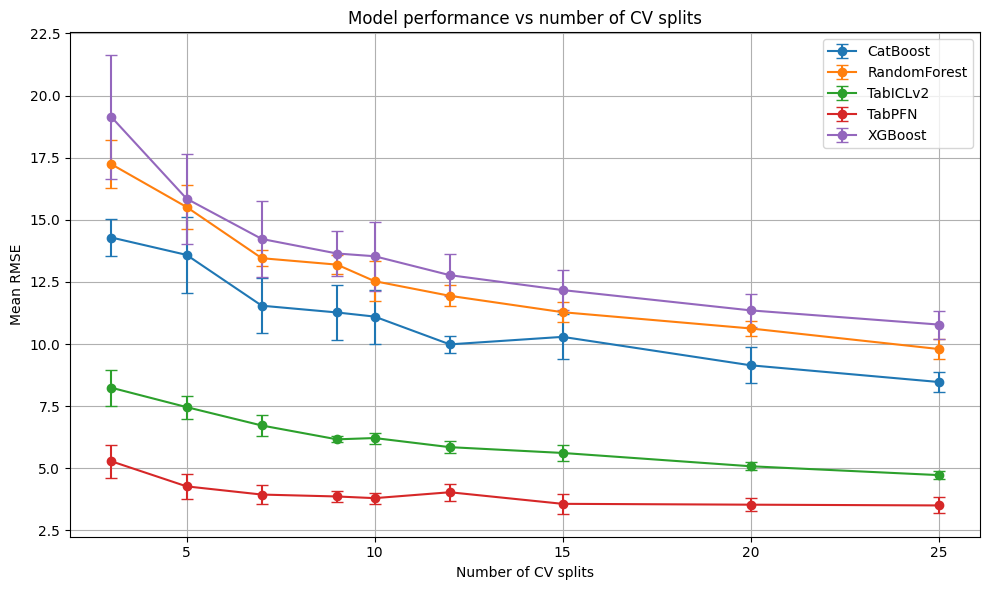

In [22]:
target_col = rate_target

subset_target = rate_summary_df[
    rate_summary_df["target"] == target_col
].copy()

plt.figure(figsize=(10, 6))

for model_name in get_present_models(subset_target):
    subset_model = subset_target[
        subset_target["model"] == model_name
    ].sort_values("n_splits")

    plt.errorbar(
        subset_model["n_splits"],
        subset_model["mean_rmse"],
        yerr=subset_model["plot_rmse_error"],
        marker="o",
        capsize=4,
        label=model_name
    )

plt.xlabel("Number of CV splits")
plt.ylabel("Mean RMSE")
plt.title("Model performance vs number of CV splits")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_figure("figure_1_reaction_rate_rmse_vs_cv_splits.png")
plt.show()

# ============================================================
# Figure 2 — Reaction rate: sMAPE vs number of CV folds
# ============================================================

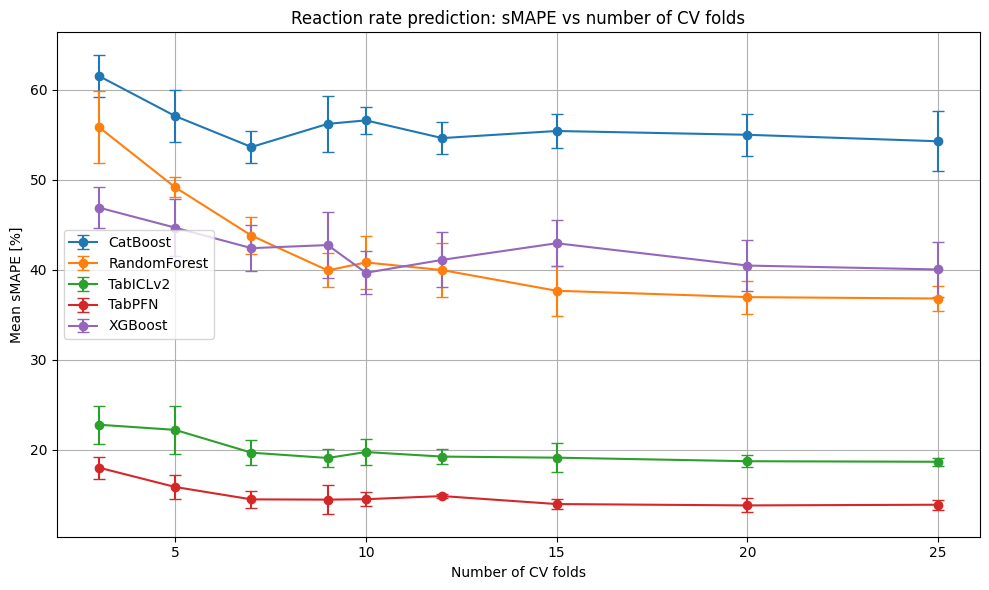

In [23]:
target_col = rate_target

subset_target = rate_summary_df[
    rate_summary_df["target"] == target_col
].copy()

plt.figure(figsize=(10, 6))

for model_name in get_present_models(subset_target):
    subset_model = subset_target[
        subset_target["model"] == model_name
    ].sort_values("n_splits")

    plt.errorbar(
        subset_model["n_splits"],
        subset_model["mean_smape"],
        yerr=subset_model["plot_smape_error"],
        marker="o",
        capsize=4,
        label=model_name
    )

plt.xlabel("Number of CV folds")
plt.ylabel("Mean sMAPE [%]")
plt.title("Reaction rate prediction: sMAPE vs number of CV folds")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_figure("figure_2_reaction_rate_smape_vs_cv_folds.png")
plt.show()

# ============================================================
# Figure 3 — CO selectivity: RMSE and variability vs CV splits
# ============================================================

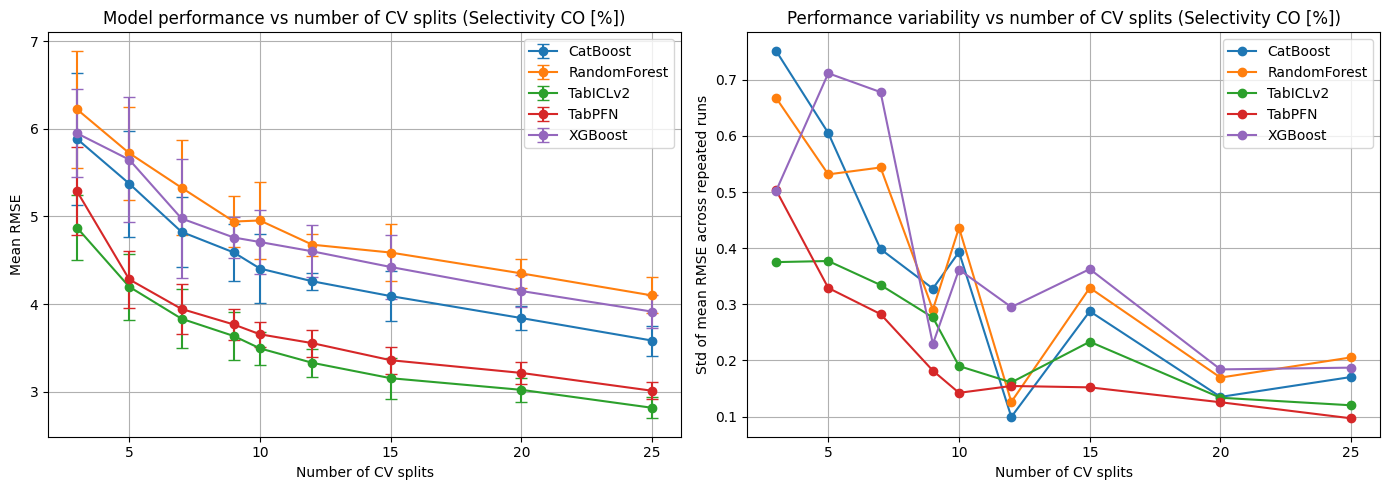

In [24]:
target_col = "Selectivity CO [%]"

subset_target = selectivity_summary_df[
    selectivity_summary_df["target"] == target_col
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A — mean RMSE
for model_name in get_present_models(subset_target):
    subset_model = subset_target[
        subset_target["model"] == model_name
    ].sort_values("n_splits")

    axes[0].errorbar(
        subset_model["n_splits"],
        subset_model["mean_rmse"],
        yerr=subset_model["plot_rmse_error"],
        marker="o",
        capsize=4,
        label=model_name
    )

axes[0].set_xlabel("Number of CV splits")
axes[0].set_ylabel("Mean RMSE")
axes[0].set_title("Model performance vs number of CV splits (Selectivity CO [%])")
axes[0].legend()
axes[0].grid(True)

# Panel B — variability
for model_name in get_present_models(subset_target):
    subset_model = subset_target[
        subset_target["model"] == model_name
    ].sort_values("n_splits")

    axes[1].plot(
        subset_model["n_splits"],
        subset_model["std_rmse"],
        marker="o",
        label=model_name
    )

axes[1].set_xlabel("Number of CV splits")
axes[1].set_ylabel("Std of mean RMSE across repeated runs")
axes[1].set_title("Performance variability vs number of CV splits (Selectivity CO [%])")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
save_figure("figure_3_co_selectivity_rmse_and_variability.png")
plt.show()

# ============================================================
# Figure 4 — CO selectivity: sMAPE vs number of CV folds
# ============================================================

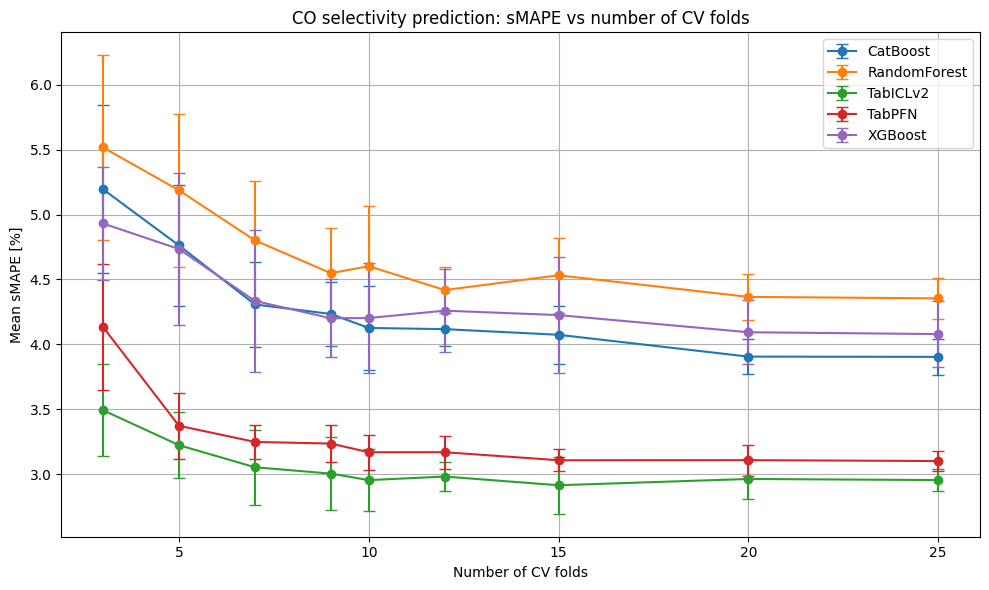

In [25]:
target_col = "Selectivity CO [%]"

subset_target = selectivity_summary_df[
    selectivity_summary_df["target"] == target_col
].copy()

plt.figure(figsize=(10, 6))

for model_name in get_present_models(subset_target):
    subset_model = subset_target[
        subset_target["model"] == model_name
    ].sort_values("n_splits")

    plt.errorbar(
        subset_model["n_splits"],
        subset_model["mean_smape"],
        yerr=subset_model["plot_smape_error"],
        marker="o",
        capsize=4,
        label=model_name
    )

plt.xlabel("Number of CV folds")
plt.ylabel("Mean sMAPE [%]")
plt.title("CO selectivity prediction: sMAPE vs number of CV folds")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_figure("figure_4_co_selectivity_smape_vs_cv_folds.png")
plt.show()

# ============================================================
# Figure 5 — CH4 and CO2 selectivity: RMSE vs CV splits
# ============================================================

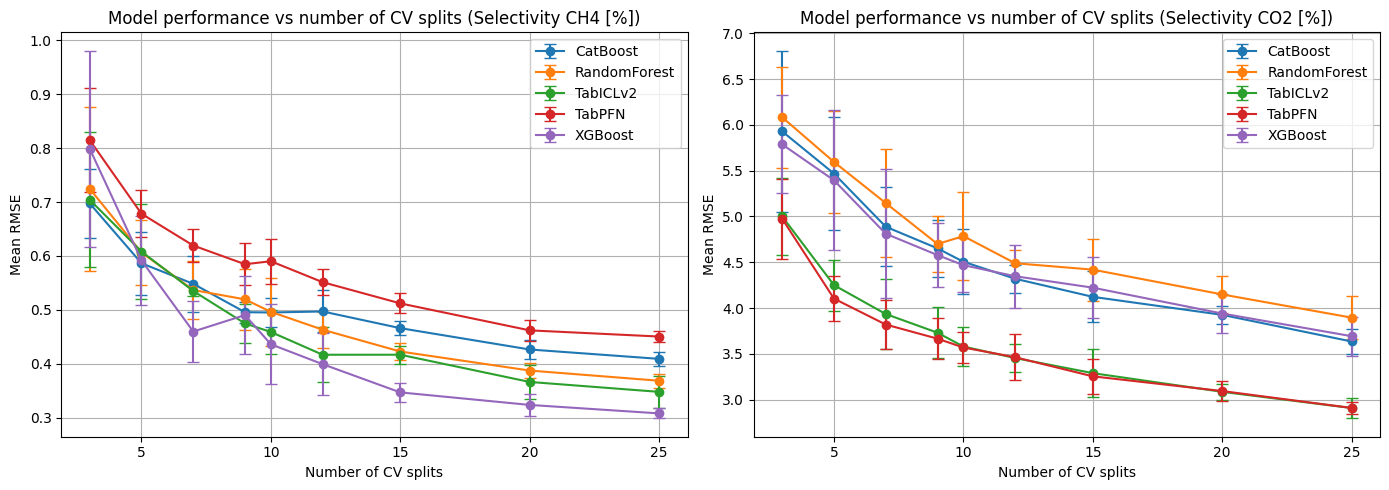

In [26]:
targets_to_plot = [
    "Selectivity CH4 [%]",
    "Selectivity CO2 [%]"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target_col in zip(axes, targets_to_plot):
    subset_target = selectivity_summary_df[
        selectivity_summary_df["target"] == target_col
    ].copy()

    for model_name in get_present_models(subset_target):
        subset_model = subset_target[
            subset_target["model"] == model_name
        ].sort_values("n_splits")

        ax.errorbar(
            subset_model["n_splits"],
            subset_model["mean_rmse"],
            yerr=subset_model["plot_rmse_error"],
            marker="o",
            capsize=4,
            label=model_name
        )

    ax.set_xlabel("Number of CV splits")
    ax.set_ylabel("Mean RMSE")
    ax.set_title(f"Model performance vs number of CV splits ({target_col})")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
save_figure("figure_5_ch4_co2_selectivity_rmse_vs_cv_splits.png")
plt.show()

# ============================================================
# Figure 6 — Selectivity model comparison at 20-fold CV
# ============================================================

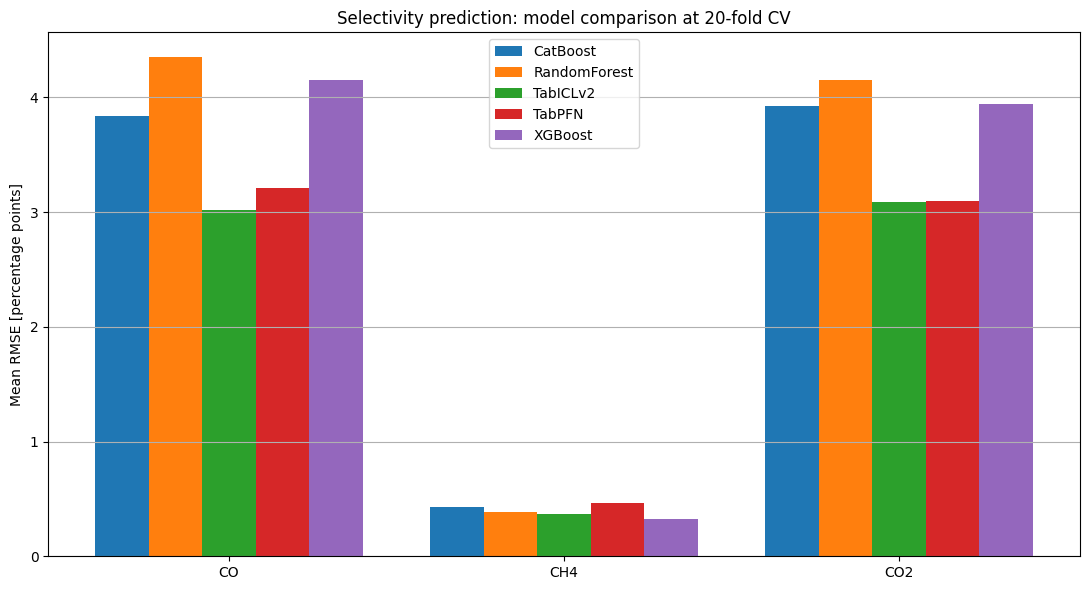

In [27]:
fixed_k_plot = 20

fixed_summary = selectivity_summary_df[
    selectivity_summary_df["n_splits"] == fixed_k_plot
].copy()

models_order = get_present_models(fixed_summary)
targets_order = selectivity_targets

x = np.arange(len(targets_order))
width = 0.8 / len(models_order)

plt.figure(figsize=(11, 6))

for i, model_name in enumerate(models_order):
    subset = fixed_summary[
        fixed_summary["model"] == model_name
    ]

    values = []

    for target in targets_order:
        target_values = subset[
            subset["target"] == target
        ]["mean_rmse"].values

        if len(target_values) == 0:
            values.append(np.nan)
        else:
            values.append(target_values[0])

    plt.bar(
        x + i * width,
        values,
        width,
        label=model_name
    )

plt.xticks(
    x + width * (len(models_order) - 1) / 2,
    ["CO", "CH4", "CO2"]
)

plt.ylabel("Mean RMSE [percentage points]")
plt.title(f"Selectivity prediction: model comparison at {fixed_k_plot}-fold CV")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
save_figure("figure_6_selectivity_model_comparison_20_fold_cv.png")
plt.show()

# ============================================================
# Figure 7 — Target-wise wrapper: sMAPE across prediction target sets
# ============================================================

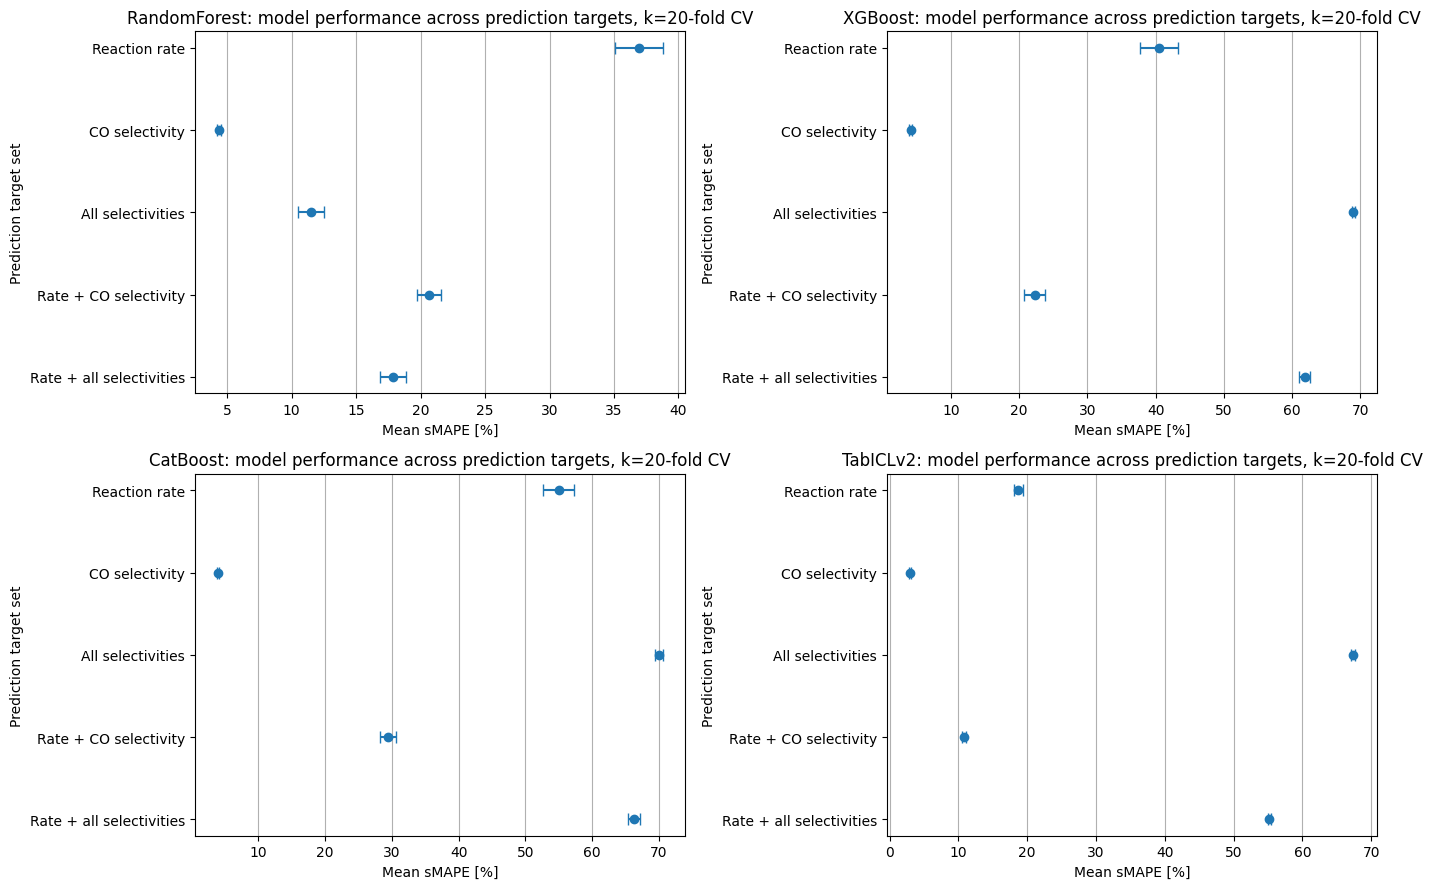

In [28]:
fixed_k_plot = 20

summary_for_plot = wrapped_multi_target_summary[
    wrapped_multi_target_summary["n_splits"] == fixed_k_plot
].copy()

models_to_plot = [
    "RandomForest",
    "XGBoost",
    "CatBoost",
    "TabICLv2"
]

models_to_plot = [
    model for model in models_to_plot
    if model in summary_for_plot["model"].unique()
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, model_name in zip(axes, models_to_plot):
    subset = summary_for_plot[
        summary_for_plot["model"] == model_name
    ].copy()

    subset = (
        subset
        .groupby("target_set", as_index=False)
        .agg(
            mean_smape=("mean_smape", "mean"),
            plot_smape_error=("plot_smape_error", "mean")
        )
    )

    subset = subset.set_index("target_set").reindex(TARGET_SET_ORDER).reset_index()
    subset = subset.dropna(subset=["mean_smape"])

    y_pos = np.arange(len(subset))

    ax.errorbar(
        subset["mean_smape"],
        y_pos,
        xerr=subset["plot_smape_error"],
        fmt="o",
        capsize=4
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(subset["target_set"])
    ax.set_xlabel("Mean sMAPE [%]")
    ax.set_ylabel("Prediction target set")
    ax.set_title(f"{model_name}: model performance across prediction targets, k={fixed_k_plot}-fold CV")
    ax.grid(axis="x")
    ax.invert_yaxis()

for ax in axes[len(models_to_plot):]:
    ax.axis("off")

plt.tight_layout()
save_figure("figure_7_targetwise_wrapper_smape_across_targets.png")
plt.show()

# ============================================================
# Figure 8 — Target-wise wrapper: Rate + all selectivities model comparison
# ============================================================

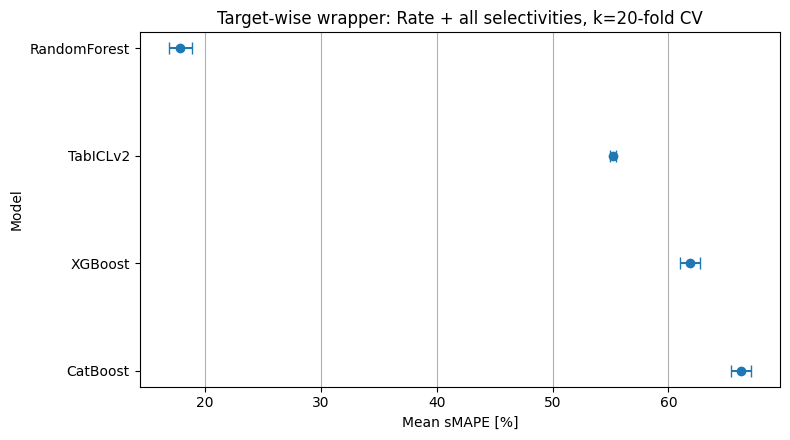

In [29]:
target_of_interest = "Rate + all selectivities"
fixed_k_plot = 20

subset = wrapped_multi_target_summary[
    (wrapped_multi_target_summary["target_set"] == target_of_interest) &
    (wrapped_multi_target_summary["n_splits"] == fixed_k_plot)
].copy()

subset = subset.sort_values("mean_smape", ascending=True)

plt.figure(figsize=(8, 4.5))

y_pos = np.arange(len(subset))

plt.errorbar(
    subset["mean_smape"],
    y_pos,
    xerr=subset["plot_smape_error"],
    fmt="o",
    capsize=4
)

plt.yticks(y_pos, subset["model"])
plt.xlabel("Mean sMAPE [%]")
plt.ylabel("Model")
plt.title(f"Target-wise wrapper: Rate + all selectivities, k={fixed_k_plot}-fold CV")
plt.grid(axis="x")
plt.gca().invert_yaxis()
plt.tight_layout()
save_figure("figure_8_targetwise_wrapper_rate_all_selectivities.png")
plt.show()

# ============================================================
# Figure 9 — Native joint-output: Rate + all selectivities model comparison
# ============================================================

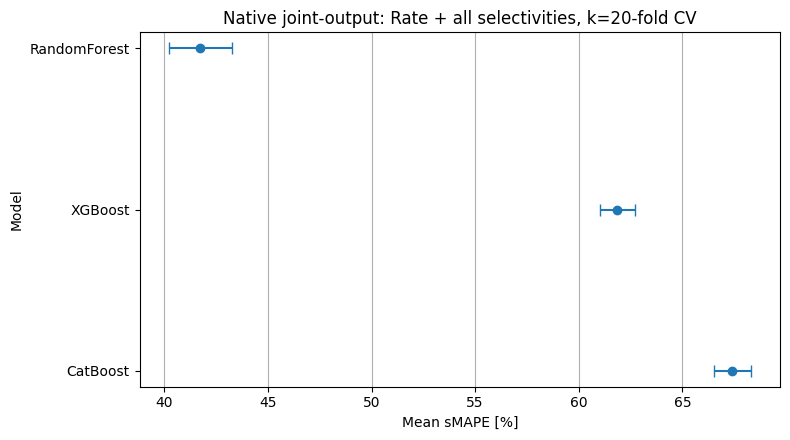

In [30]:
target_of_interest = "Rate + all selectivities"
fixed_k_plot = 20

subset = native_multi_target_summary[
    (native_multi_target_summary["target_set"] == target_of_interest) &
    (native_multi_target_summary["n_splits"] == fixed_k_plot)
].copy()

subset = subset.sort_values("mean_smape", ascending=True)

plt.figure(figsize=(8, 4.5))

y_pos = np.arange(len(subset))

plt.errorbar(
    subset["mean_smape"],
    y_pos,
    xerr=subset["plot_smape_error"],
    fmt="o",
    capsize=4
)

plt.yticks(y_pos, subset["model"])
plt.xlabel("Mean sMAPE [%]")
plt.ylabel("Model")
plt.title(f"Native joint-output: Rate + all selectivities, k={fixed_k_plot}-fold CV")
plt.grid(axis="x")
plt.gca().invert_yaxis()
plt.tight_layout()
save_figure("figure_9_native_joint_output_rate_all_selectivities.png")
plt.show()